<a href="https://colab.research.google.com/github/iamclowdee/Student-Placement-Prediction-ML-IPYNB-/blob/main/Student_Placement_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
#Cell 2: Dummy dataset

import pandas as pd

data = {
    "CGPA":[8.9,8.5,9.1,7.8,8.2,6.5,6.8,7.0,7.2,7.4],
    "Internships":[3,2,4,1,2,0,0,1,1,1],
    "Projects":[5,4,6,3,4,1,2,2,3,3],
    "Workshops":[4,3,5,2,3,1,1,1,2,2],
    "AptitudeTestScore":[92,88,95,75,82,55,58,62,65,68],
    "SoftSkillsRating":[9,8,10,7,8,5,5,6,6,7],
    "PlacementStatus":[1,1,1,1,1,0,0,0,0,0]
}

df = pd.DataFrame(data)

df.to_csv("placement.csv", index=False)

print("placement.csv created successfully!")

placement.csv created successfully!


In [5]:
# Cell 3: Load dataset

# FileNotFoundError: The file 'placement.csv' was not found. Please ensure the file is uploaded
# to your Colab environment or provide the correct path to the file.
df = pd.read_csv("placement.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,CGPA,Internships,Projects,Workshops,AptitudeTestScore,SoftSkillsRating,PlacementStatus
0,8.9,3,5,4,92,9,1
1,8.5,2,4,3,88,8,1
2,9.1,4,6,5,95,10,1
3,7.8,1,3,2,75,7,1
4,8.2,2,4,3,82,8,1


In [6]:
# Cell 4: Explore Data

print("Shape:", df.shape)

print("\nPlacement Count:\n")
print(df["PlacementStatus"].value_counts())

print("\nMissing Values:\n")
print(df.isnull().sum())

df.describe()

Shape: (10, 7)

Placement Count:

PlacementStatus
1    5
0    5
Name: count, dtype: int64

Missing Values:

CGPA                 0
Internships          0
Projects             0
Workshops            0
AptitudeTestScore    0
SoftSkillsRating     0
PlacementStatus      0
dtype: int64


,CGPA,Internships,Projects,Workshops,AptitudeTestScore,SoftSkillsRating,PlacementStatus
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000
mean,7.740000,1.500000,3.300000,2.400000,74.000000,7.10000,0.500000
std,0.904556,1.269296,1.494434,1.349897,14.544949,1.66333,0.527046
min,6.500000,0.000000,1.000000,1.000000,55.000000,5.00000,0.000000
25%,7.050000,1.000000,2.250000,1.250000,62.750000,6.00000,0.000000
50%,7.600000,1.000000,3.000000,2.000000,71.500000,7.00000,0.500000
75%,8.425000,2.000000,4.000000,3.000000,86.500000,8.00000,1.000000
max,9.100000,4.000000,6.000000,5.000000,95.000000,10.00000,1.000000


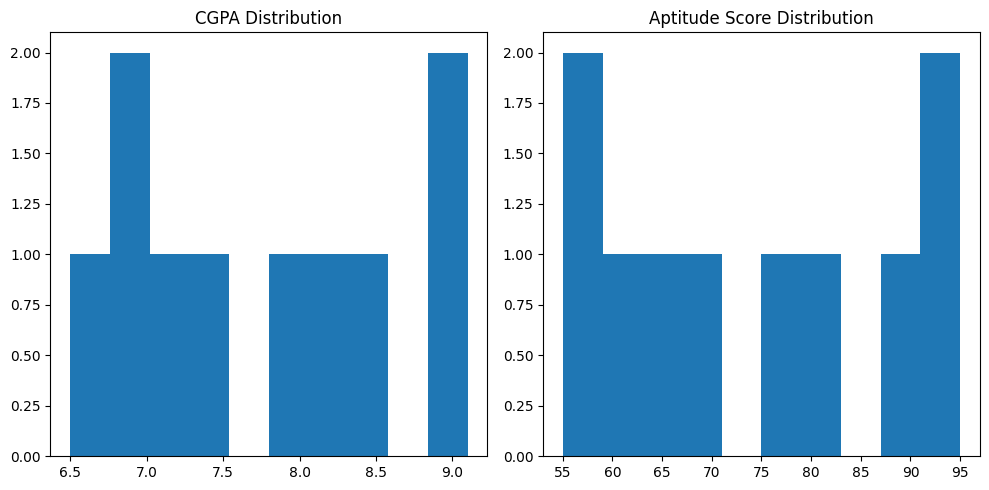

In [7]:
# Cell 5: Visualizations

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(df["CGPA"], bins=10)
plt.title("CGPA Distribution")

plt.subplot(1,2,2)
plt.hist(df["AptitudeTestScore"], bins=10)
plt.title("Aptitude Score Distribution")

plt.tight_layout()
plt.show()

In [8]:
# Cell 6: Separate Features and Labels

X = df.drop("PlacementStatus", axis=1)

y = df["PlacementStatus"]

print("Features Shape:", X.shape)
print("Labels Shape:", y.shape)

Features Shape: (10, 6)
Labels Shape: (10,)


In [9]:
# Cell 7: Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 8
Testing Samples: 2


In [10]:
# Cell 8: Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [11]:
# Cell 9: Train KNN Model

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

print("KNN Model Trained!")

KNN Model Trained!


In [12]:
# Cell 10: Train KNN Model

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

print("KNN Model Trained!")

KNN Model Trained!


In [14]:
# Cell 11: Evaluate Models

# Initialize and train the Logistic Regression model
lr = LogisticRegression(random_state=42) # Added random_state for reproducibility
lr.fit(X_train, y_train)

knn_predictions = knn.predict(X_test)

lr_predictions = lr.predict(X_test)

knn_acc = accuracy_score(y_test, knn_predictions)

lr_acc = accuracy_score(y_test, lr_predictions)

print(f"KNN Accuracy: {knn_acc*100:.2f}%")

print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

KNN Accuracy: 100.00%
Logistic Regression Accuracy: 100.00%


In [16]:
# Cell 12: Confusion Matrix

cm = confusion_matrix(y_test, knn_predictions)

print("Confusion Matrix:")

print(cm)

cm_df = pd.DataFrame(
    cm,
    index=["Not Placed","Placed"],
    columns=["Not Placed","Placed"]
)

print(cm_df)

Confusion Matrix:
[[1 0]
 [0 1]]
            Not Placed  Placed
Not Placed           1       0
Placed               0       1


In [17]:
# Cell 13: Confusion Matrix

cm = confusion_matrix(y_test, knn_predictions)

print("Confusion Matrix:")

print(cm)

cm_df = pd.DataFrame(
    cm,
    index=["Not Placed","Placed"],
    columns=["Not Placed","Placed"]
)

print(cm_df)

Confusion Matrix:
[[1 0]
 [0 1]]
            Not Placed  Placed
Not Placed           1       0
Placed               0       1
